# GoalLab Stage 13: Search investigation branches under a budget

Created by Shivam Bharadwaj · [Course home](../../../README.md) · [Stage map](../STAGES.md)

[Stage 12](12_sampling_and_selection.ipynb) · [Stage 14](14_learning_from_search.ipynb)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bshivambharadwaj/Reinforcement-Learning-Course/blob/main/projects/goallab/notebooks/13_budgeted_reasoning_search.ipynb)

**Build:** branch the shared workspace session, rank partial investigations, and enforce a common search budget.

**Run:** use the full repository, install `requirements.txt` (Stage 09 also uses `requirements-modern.txt`), then restart the kernel and run all cells. Every stage reconstructs its inputs from shared GoalLab modules; earlier notebook execution is not required. The project progression is cumulative in capabilities, without hidden notebook state.

Code: MIT. Text and plots: CC BY 4.0. Results below are reproduced from the supplied GoalLab cases; the evaluation section explains their scope and failure cases.

**Learn the algorithm first:** [Course Notebook 13](../../../notebooks/13_budgeted_reasoning_search.ipynb). Then use this GoalLab stage to apply it to evidence gathering and briefing verification.


In [1]:
import sys, subprocess, platform, tempfile, json
from pathlib import Path
IN_COLAB = 'google.colab' in sys.modules
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'rl_course').is_dir()), Path.cwd())
if IN_COLAB and not (ROOT / 'rl_course').exists():
    ROOT = Path('/content/Reinforcement-Learning-Course')
    if not ROOT.exists():
        subprocess.run(['git', 'clone', '--depth', '1', 'https://github.com/bshivambharadwaj/Reinforcement-Learning-Course.git', str(ROOT)], check=True)
if not (ROOT / 'rl_course' / 'goallab.py').exists():
    raise FileNotFoundError('Use the complete repository revision containing the GoalLab stages.')
sys.path.insert(0, str(ROOT))
import numpy as np, torch, matplotlib.pyplot as plt
from IPython.display import Markdown, display
from rl_course import goallab as goal
from rl_course import goallab_learning as learning
torch.set_num_threads(2)
%matplotlib inline
INK, GOLD, SAGE, PLUM, PAPER = '#292332', '#af824a', '#768165', '#87708c', '#f5f1e8'
plt.rcParams.update({'figure.figsize': (9, 4), 'figure.dpi': 110, 'figure.facecolor': PAPER,
    'axes.facecolor': PAPER, 'text.color': INK, 'axes.labelcolor': INK,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.prop_cycle': plt.cycler(color=[GOLD, SAGE, PLUM, INK]), 'axes.grid': True, 'grid.alpha': .15})
def table(headers, rows):
    display(Markdown('| ' + ' | '.join(headers) + ' |\n|' + '|'.join(['---'] * len(headers)) + '|\n' +
        '\n'.join('| ' + ' | '.join(str(x).replace('|', '&#124;').replace('\n', '<br>') for x in row) + ' |' for row in rows)))
def learning_plot(runs):
    for label, run in runs.items():
        h = run['history']
        plt.plot(h[:, 0], h[:, 1], label=label)
    plt.xlabel('Training environment actions'); plt.ylabel('Exact policy return')
    plt.legend(); plt.tight_layout(); plt.show()
def report_policies(runs):
    table(['Controller', 'Exact return', 'Held-out briefing success', 'Calls/case'],
          [[label, round(run['env'].values(run['policy'])[0][run['env'].start_index], 3),
            f"{learning.heldout(run['policy'])['success']:.1%}", learning.heldout(run['policy'])['calls']]
           for label, run in runs.items()])
workspace = goal.make_workspace(7, 'test')
print(f'{goal.VERSION} | Python {platform.python_version()} | NumPy {np.__version__} | Torch {torch.__version__} | CPU')

GoalLab-v1 | Python 3.12.4 | NumPy 1.26.4 | Torch 2.11.0+cu130 | CPU


## Shared contract

One source is an approved measurement for the requested period. Other sources are drafts or forecasts, deliberately newer and numerically different. Training rows use 0..3; held-out rows use 4..7 and a different period. Authority rules stay the same. `search` reveals IDs and timestamps; `read` reveals content. A valid briefing needs the correct value, period, and citation.

The simulator and models are readable teaching code, not a security boundary. Final `verify()` is outside the policy interface. The first eight stages use a finite two-source abstraction: read twice, choose a citation, then submit or claim completion. Claiming completion produces no briefing. This fixed horizon makes exact comparisons possible; later stages vary investigation budgets.

## Learning objectives and the stage contract

Implement bounded branch expansion; distinguish copied session state from shared state; account for unfinished search.

**Input:** the shared evidence workspace or the preceding component reconstructed below. **Output:** the capability named in this stage, evaluated against the common briefing contract. Read the worked calculation before running the full experiment; then inspect the implementation and predict the constraint exercise.

## Work it out: branching can consume the allowance before completion

A width-two beam with branching two expands 2 children at depth one, 4 at depth two, and 4 at depth three. At one proposal plus one score unit per child, the full pass costs 20 units. A complete binary tree to depth three has 14 expansions and costs 28 units.

Best-first can use a different order and reach a leaf sooner, but that does not guarantee a better selected artifact. All work on abandoned branches still counts.

In [2]:
beam_expansions=2+4+4
full_tree_expansions=2+4+8
table(['Strategy structure','Expansions','Cost at score=1','Cost at score=3'],
      [['Width-two beam',beam_expansions,beam_expansions*2,beam_expansions*4],['Full binary tree',full_tree_expansions,full_tree_expansions*2,full_tree_expansions*4]])
assert beam_expansions*2==20 and full_tree_expansions*2==28

| Strategy structure | Expansions | Cost at score=1 | Cost at score=3 |
|---|---|---|---|
| Width-two beam | 10 | 20 | 40 |
| Full binary tree | 14 | 28 | 56 |

## Build the component

The central implementation is included here so you can step through and edit the update or tool logic. The shared modules retain the same reference implementation for the integrated project. Inspect shapes, terminal handling, frozen quantities, and the evaluator boundary before training.

In [3]:
from collections import Counter
import random
from rl_course import goallab_search as shared_search
Session=goal.Session
FrozenProposer=shared_search.FrozenProposer
METHODS=shared_search.METHODS
score=shared_search.score
artifact=shared_search.artifact
def investigate(workspace, method='best_of_n', budget=24, seed=7, signal='evidence',
           policy=None, score_cost=1, width=2, branching=2):
    if method not in METHODS or signal not in {'evidence', 'misleading'}:
        raise ValueError('unknown method or scorer')
    if any(not isinstance(v, int) for v in (budget, score_cost, width, branching)) or budget < 0 or min(score_cost, width, branching) < 1:
        raise ValueError('invalid budget/search configuration')
    policy, rng = policy or FrozenProposer(), random.Random(seed)
    spent = proposals = scores = 0
    events, completed = [], []

    def expand(node, scored=True):
        nonlocal spent, proposals, scores
        prefix, session, _ = node
        if spent + 1 + (score_cost if scored else 0) > budget:
            return None
        action = policy.propose(session, prefix, rng)
        child_session = session.snapshot()
        child = prefix + (action,)
        if not prefix:
            child_session.execute('read', action)
        spent += 1; proposals += 1
        value = score(child_session, child, signal) if scored else 0.
        if scored:
            spent += score_cost; scores += 1
        events.append({'prefix': child, 'score': value if scored else None, 'spent': spent})
        return child, child_session, value

    root = ((), Session(workspace, budget=4), 0.)
    if method in {'single', 'self_consistency', 'best_of_n'}:
        per_candidate = 3 + (score_cost if method == 'best_of_n' else 0)
        while spent + per_candidate <= budget:
            node = root
            for _ in range(3):
                node = expand(node, scored=False)
            if method == 'best_of_n':
                spent += score_cost; scores += 1
                node = (node[0], node[1], score(node[1], node[0], signal))
            completed.append(node)
            if method == 'single':
                break
    else:
        frontier = [root]
        while frontier and spent + 1 + score_cost <= budget:
            if method == 'beam':
                parents, frontier = frontier, []
            else:
                # Score, then deeper prefix; stable order resolves remaining ties.
                frontier.sort(key=lambda n: (n[2], len(n[0])), reverse=True)
                parents = [frontier.pop(0)]
            children = []
            for parent in parents:
                for _ in range(branching):
                    child = expand(parent)
                    if child is None:
                        break
                    if len(child[0]) == 3:
                        completed.append(child)
                    else:
                        children.append(child)
            if method == 'beam':
                frontier = sorted(children, key=lambda n: n[2], reverse=True)[:width]
            else:
                frontier.extend(children)
    selected = None
    if completed:
        if method == 'self_consistency':
            # Vote on final numerical answer; first observed candidate wins a tie.
            counts = Counter(artifact(s, p).value for p, s, _ in completed)
            answer = counts.most_common(1)[0][0]
            selected = next(n for n in completed if artifact(n[1], n[0]).value == answer)
        else:
            selected = max(completed, key=lambda n: n[2])
    result = artifact(selected[1], selected[0]) if selected else None
    return {'artifact': result, 'prefix': selected[0] if selected else None,
            'candidates': [artifact(s, p) for p, s, _ in completed],
            'events': events, 'spent': spent, 'proposals': proposals, 'score_calls': scores,
            'session': selected[1] if selected else None}

probe=investigate(workspace,"best_first",24,7)
assert probe["spent"]<=24
print("Local search spent:",probe["spent"])

Local search spent: 24


## 1. Search partial evidence trajectories

Sampled beam search retains two prefixes per depth after proposing two children per parent. Best-first expands the highest-scoring prefix, breaking score ties by depth and insertion order. These are finite sampled trees, not MCTS. Duplicate proposals still cost work.

Every extension costs one proposal unit; scored prefixes cost one additional unit by default. Each source read happens in a cloned session. Branches cannot mutate each other's reads or events. If no complete candidate exists, the method abstains.

| Method | Budget | Verified success | Oracle opportunity | Spent | Completion |
|---|---|---|---|---|---|
| single | 6 | 0.133 | 0.133 | 3.0 | 1.0 |
| self_consistency | 6 | 0.133 | 0.233 | 6.0 | 1.0 |
| best_of_n | 6 | 0.133 | 0.133 | 4.0 | 1.0 |
| beam | 6 | 0.0 | 0.0 | 6.0 | 0.0 |
| best_first | 6 | 0.0 | 0.0 | 6.0 | 0.0 |
| single | 12 | 0.133 | 0.133 | 3.0 | 1.0 |
| self_consistency | 12 | 0.079 | 0.388 | 12.0 | 1.0 |
| best_of_n | 12 | 0.308 | 0.308 | 12.0 | 1.0 |
| beam | 12 | 0.0 | 0.0 | 12.0 | 0.0 |
| best_first | 12 | 0.404 | 0.404 | 12.0 | 0.996 |
| single | 24 | 0.133 | 0.133 | 3.0 | 1.0 |
| self_consistency | 24 | 0.067 | 0.679 | 24.0 | 1.0 |
| best_of_n | 24 | 0.558 | 0.558 | 24.0 | 1.0 |
| beam | 24 | 0.404 | 0.404 | 20.0 | 1.0 |
| best_first | 24 | 0.408 | 0.408 | 24.0 | 1.0 |
| single | 48 | 0.133 | 0.133 | 3.0 | 1.0 |
| self_consistency | 48 | 0.042 | 0.9 | 48.0 | 1.0 |
| best_of_n | 48 | 0.817 | 0.817 | 48.0 | 1.0 |
| beam | 48 | 0.404 | 0.404 | 20.0 | 1.0 |
| best_first | 48 | 0.408 | 0.408 | 28.0 | 1.0 |

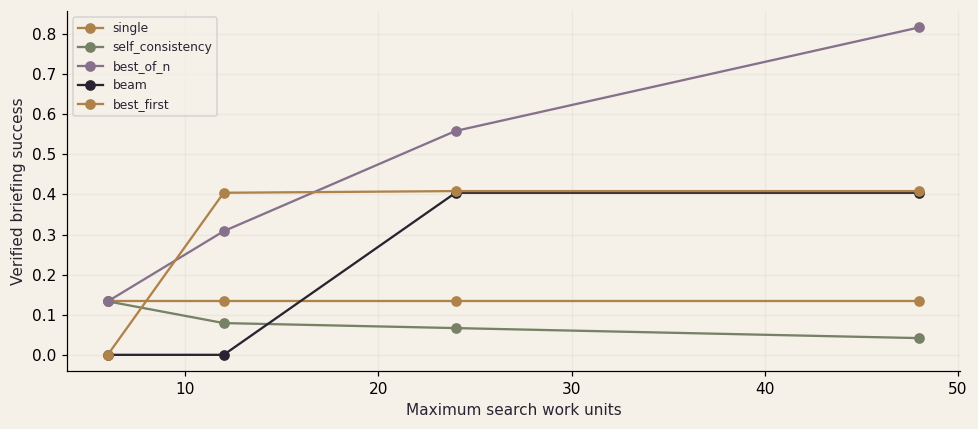

| Prefix (source, offset, citation) | Visible score | Cumulative spend |
|---|---|---|
| (0,) | 0.0 | 2 |
| (0,) | 0.0 | 4 |
| (0, 1) | 0.0 | 6 |
| (0, 0) | 0.5 | 8 |
| (0, 0, 0) | 0.6666666666666666 | 10 |
| (0, 0, 0) | 0.6666666666666666 | 12 |
| (0, 1, 0) | 0.3333333333333333 | 14 |
| (0, 1, 0) | 0.3333333333333333 | 16 |
| (0, 0) | 0.5 | 18 |
| (0, 0) | 0.5 | 20 |
| (0, 0, 0) | 0.6666666666666666 | 22 |
| (0, 0, 0) | 0.6666666666666666 | 24 |

In [4]:
from rl_course import goallab_search as search
def summarize(rows):
    groups={}
    for r in rows: groups.setdefault((r['method'],r['budget']),[]).append(r)
    table(['Method','Budget','Verified success','Oracle opportunity','Spent','Completion'],
          [[m,b,*[round(np.mean([r[k] for r in rs]),3) for k in ['success','oracle','spent','completion']]] for (m,b),rs in groups.items()])
def search_plot(rows):
    for method in dict.fromkeys(r['method'] for r in rows):
        group=[r for r in rows if r['method']==method]
        budgets=sorted({r['budget'] for r in group})
        plt.plot(budgets,[np.mean([r['success'] for r in group if r['budget']==b]) for b in budgets],marker='o',label=method)
    plt.xlabel('Maximum search work units'); plt.ylabel('Verified briefing success'); plt.legend(fontsize=8); plt.tight_layout(); plt.show()

rows=search.benchmark(cases=80)
summarize(rows); search_plot(rows)
run=investigate(workspace,'best_first',24,7)
table(['Prefix (source, offset, citation)','Visible score','Cumulative spend'],[[e['prefix'],e['score'],e['spent']] for e in run['events']])

## 2. Separate final evaluation from search feedback

The prefix checker uses already-read source eligibility, extraction consistency, and citation consistency. This exact rule checker is not a learned value model. Protect the final evaluation boundary even though this synthetic authority rule makes a strong visible checker possible.

In [5]:
from unittest.mock import patch
with patch.object(search,'verify',side_effect=AssertionError('Final evaluator leaked into search')):
    isolated=investigate(workspace,'beam',24,7)
print('Independent post-search check:',goal.verify(workspace,isolated['artifact']))
assert run['spent']==run['proposals']+run['score_calls']

Independent post-search check: {'success': False, 'supported': False, 'value_correct': False}


## Interpret the evidence

A search method can exhaust its finite tree before spending its entire cap. Another can consume the cap without a complete candidate. Report completed artifacts and actual work together; the cap alone does not explain behavior.

## Change a constraint: predict first

Increase score cost to three. Under the same cap, which strategies can still complete an investigation? Do not compare only the cap; inspect actual spending.

### Worked solution

Run this after writing your prediction. Compare the changed condition with the reference condition above.

In [6]:
expensive=search.benchmark(cases=40,budgets=(12,24),seeds=(7,),score_cost=3)
summarize(expensive)
print('Self-consistency does not query the scorer; tree search pays at every expanded prefix.')

| Method | Budget | Verified success | Oracle opportunity | Spent | Completion |
|---|---|---|---|---|---|
| single | 12 | 0.15 | 0.15 | 3.0 | 1.0 |
| self_consistency | 12 | 0.05 | 0.425 | 12.0 | 1.0 |
| best_of_n | 12 | 0.3 | 0.3 | 12.0 | 1.0 |
| beam | 12 | 0.0 | 0.0 | 12.0 | 0.0 |
| best_first | 12 | 0.0 | 0.0 | 12.0 | 0.0 |
| single | 24 | 0.15 | 0.15 | 3.0 | 1.0 |
| self_consistency | 24 | 0.1 | 0.65 | 24.0 | 1.0 |
| best_of_n | 24 | 0.425 | 0.425 | 24.0 | 1.0 |
| beam | 24 | 0.0 | 0.0 | 24.0 | 0.0 |
| best_first | 24 | 0.35 | 0.35 | 24.0 | 1.0 |

Self-consistency does not query the scorer; tree search pays at every expanded prefix.


## What this stage contributes

A budgeted evidence-search engine with isolated branch state and evaluator boundaries. Theory: [search](../../../chapters/45-search-over-reasoning-trajectories/README.md), [budgets](../../../chapters/46-budget-aware-reasoning/README.md).

[Stage 12](12_sampling_and_selection.ipynb) · [Stage 14](14_learning_from_search.ipynb)